# Boosting — An Illustrated Tour

> Train weak learners **sequentially**, each one focusing on what the previous ones got wrong. Combine them into a strong predictor that drives **bias** down, the opposite emphasis of bagging.

---

**What we cover:**
- AdaBoost — reweight misclassified points, vote on stumps
- Gradient Boosting — fit each tree to the **residual** (negative gradient)
- Staged predictions — watch the boundary sharpen
- Learning rate × # estimators trade-off
- Why boosting can overfit if you crank the budget too high

## The picture — sequential weak learners, each focused on the previous mistakes

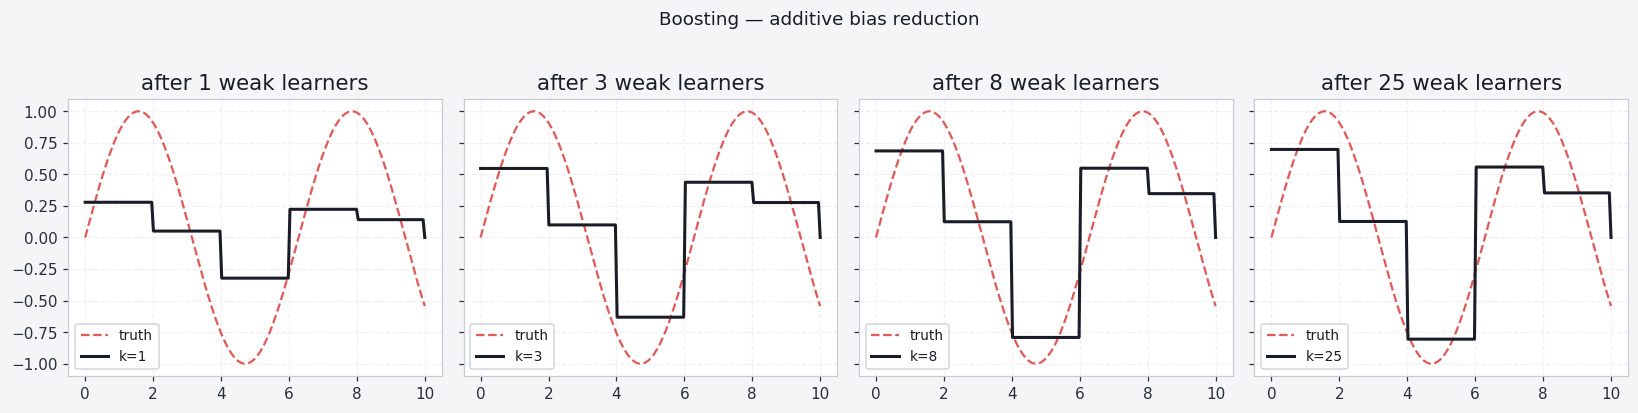

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
x = np.linspace(0, 10, 200); y = np.sin(x)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, k in zip(axes, [1, 3, 8, 25]):
    p = np.zeros_like(x)
    for _ in range(k):
        r = y - p; cuts = np.linspace(0, 10, 6)
        for i in range(5):
            mask = (x>=cuts[i]) & (x<cuts[i+1]); p[mask] += 0.4 * r[mask].mean()
    ax.plot(x, y, color=P[1], lw=1.5, ls='--', label='truth')
    ax.plot(x, p, color='#1a1d27', lw=2, label=f'k={k}')
    ax.set_title(f'after {k} weak learners'); ax.grid(True); ax.legend(fontsize=9)
fig.suptitle('Boosting — additive bias reduction', y=1.03)
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

rng = np.random.default_rng(0)
X, y = make_moons(n_samples=180, noise=0.25, random_state=0)
x = np.sort(rng.uniform(-3, 3, 80))
yreg = np.sin(2*x) + 0.3*x + rng.normal(0, 0.4, 80)
Xreg = x.reshape(-1, 1)
xs = np.linspace(-3.2, 3.2, 400).reshape(-1, 1)

---
## AdaBoost — Reweighting

Initialise sample weights $w_i = 1/n$.
For $t = 1 \dots T$:
1. Train weak classifier $h_t$ to minimise weighted error $\varepsilon_t = \sum_i w_i\, \mathbb{1}[h_t(x_i) \neq y_i]$.
2. Compute classifier weight $\alpha_t = \tfrac12 \log\!\bigl(\tfrac{1-\varepsilon_t}{\varepsilon_t}\bigr)$.
3. **Up-weight misclassified** points: $w_i \leftarrow w_i \exp\!\bigl(-\alpha_t y_i h_t(x_i)\bigr)$, then normalise.

Final prediction: $H(x) = \operatorname{sign}\!\bigl(\sum_t \alpha_t h_t(x)\bigr)$.

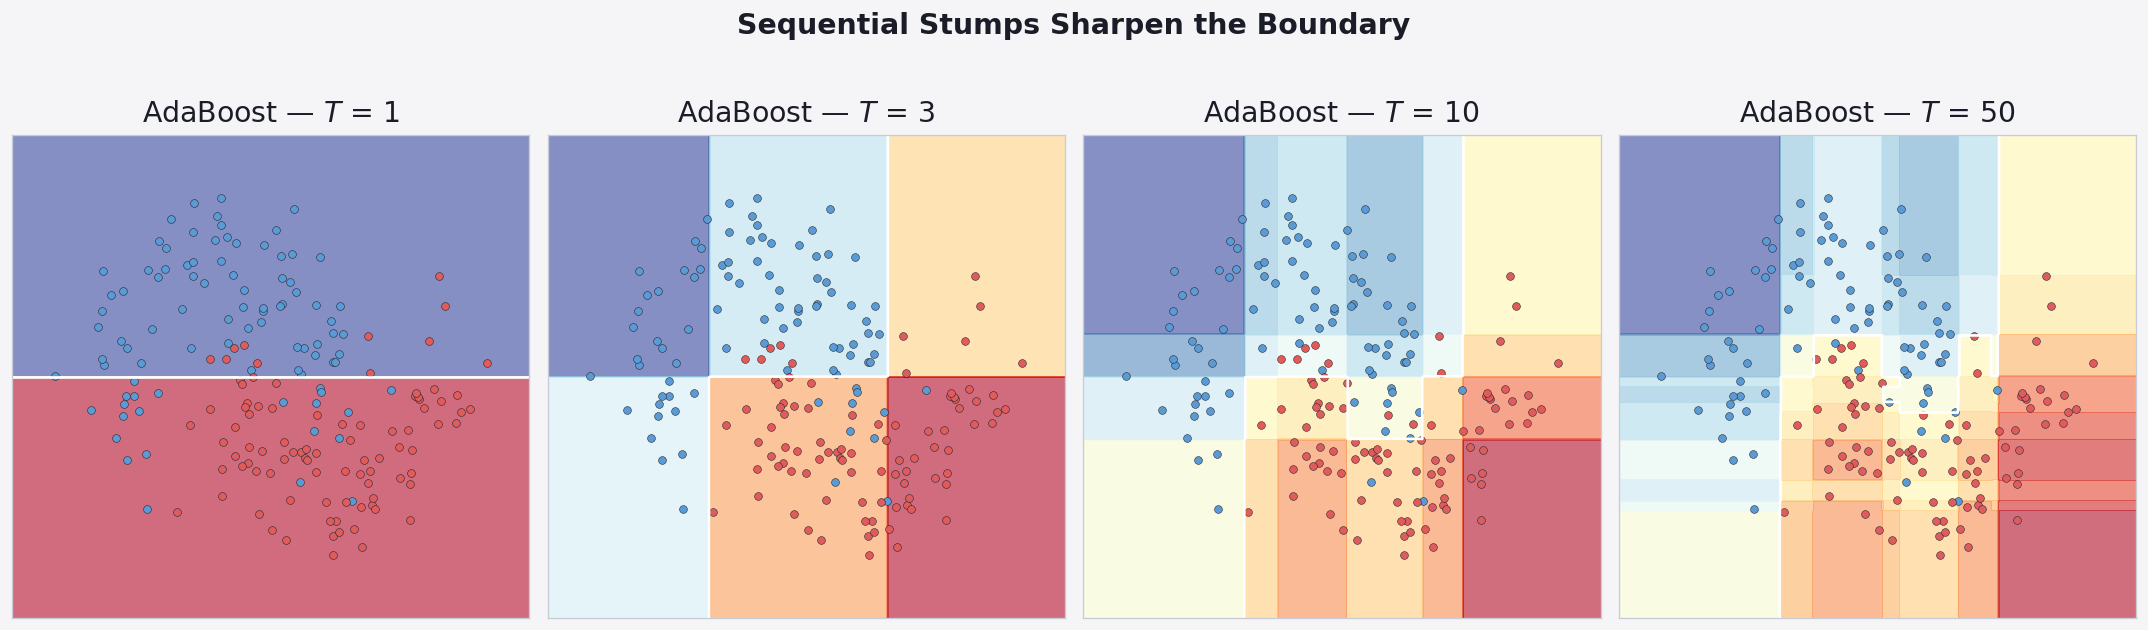

In [3]:
stages = [1, 3, 10, 50]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.4, X[:,0].max()+0.4, 300),
                     np.linspace(X[:,1].min()-0.4, X[:,1].max()+0.4, 300))
for ax, T in zip(axes, stages):
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=T, learning_rate=1.0, random_state=0).fit(X, y)
    Z = ada.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0], colors='#ffffff', linewidths=1.6)
    ax.scatter(X[y==0,0], X[y==0,1], c=C0, s=22, edgecolors='#1a1d27', lw=0.3)
    ax.scatter(X[y==1,0], X[y==1,1], c=C1, s=22, edgecolors='#1a1d27', lw=0.3)
    ax.set_title(f'AdaBoost — $T$ = {T}', pad=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Sequential Stumps Sharpen the Boundary', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## Gradient Boosting — Fitting Residuals

Generalises AdaBoost to any differentiable loss $L$. After $t$ rounds the model is $F_t$. The next learner $h_{t+1}$ is fit to the **negative gradient** (the *pseudo-residual*):

$$r_i^{(t)} = -\frac{\partial L\bigl(y_i,\, F_t(x_i)\bigr)}{\partial F_t(x_i)}, \qquad F_{t+1}(x) = F_t(x) + \eta\, h_{t+1}(x).$$

For squared error, the residuals are simply $y_i - F_t(x_i)$. The learning rate $\eta$ shrinks each step — small $\eta$ + many trees usually beats large $\eta$ + few trees.

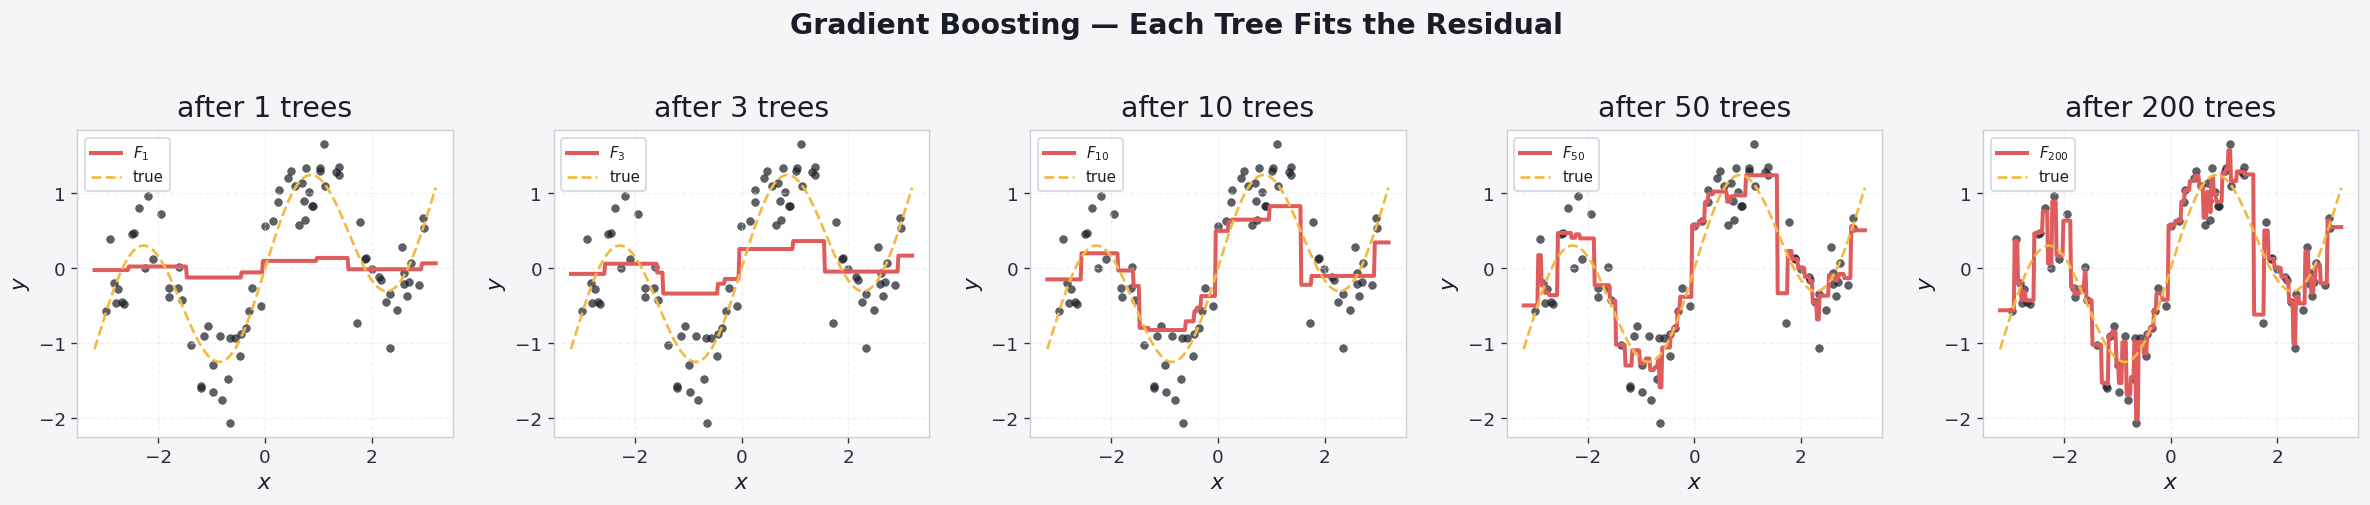

In [4]:
stages_r = [1, 3, 10, 50, 200]
fig, axes = plt.subplots(1, len(stages_r), figsize=(20, 4))
gb = GradientBoostingRegressor(n_estimators=max(stages_r), max_depth=3,
                                learning_rate=0.1, random_state=0).fit(Xreg, yreg)
preds_iter = list(gb.staged_predict(xs))
for ax, T in zip(axes, stages_r):
    ax.scatter(x, yreg, c='#1a1d27', s=22, edgecolors='#1a1d27', lw=0.3, alpha=0.7)
    ax.plot(xs, preds_iter[T-1], color=C1, lw=2.4, label=f'$F_{{{T}}}$')
    ax.plot(xs, np.sin(2*xs.ravel()) + 0.3*xs.ravel(), color=CB, lw=1.6, ls='--', label='true')
    ax.set_title(f'after {T} trees', pad=8); ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.grid(True); ax.legend(loc='upper left', fontsize=9)
fig.suptitle('Gradient Boosting — Each Tree Fits the Residual', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## Learning Rate vs # Estimators

Lower $\eta$ needs more trees but generalises better.
Plot **train** and **validation** loss vs the staged predictions for two $\eta$ values.

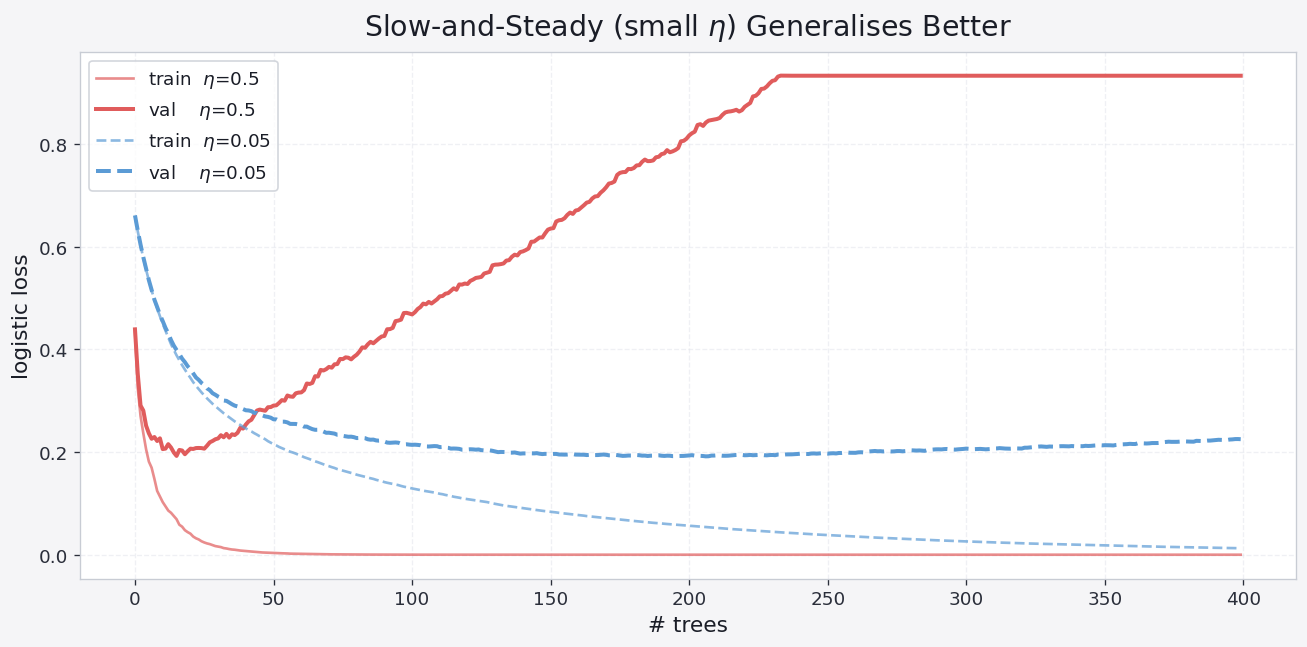

In [5]:
from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.4, random_state=0)

fig, ax = plt.subplots(figsize=(11, 5.5))
for eta, color, ls in [(0.5, C1, '-'), (0.05, C0, '--')]:
    g = GradientBoostingClassifier(n_estimators=400, max_depth=2,
                                    learning_rate=eta, random_state=0).fit(Xtr, ytr)
    train_loss = []; val_loss = []
    for p_tr, p_te in zip(g.staged_decision_function(Xtr), g.staged_decision_function(Xte)):
        # logistic loss with labels in {-1, +1}
        train_loss.append(np.mean(np.log1p(np.exp(-(2*ytr-1) * p_tr.ravel()))))
        val_loss.append(np.mean(np.log1p(np.exp(-(2*yte-1) * p_te.ravel()))))
    ax.plot(train_loss, color=color, lw=1.6, ls=ls, alpha=0.7, label=f'train  $\\eta$={eta}')
    ax.plot(val_loss,   color=color, lw=2.4, ls=ls, label=f'val    $\\eta$={eta}')
ax.set_xlabel('# trees'); ax.set_ylabel('logistic loss')
ax.set_title('Slow-and-Steady (small $\\eta$) Generalises Better', pad=10)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use Boosting — and when not to

| Situation | AdaBoost | Gradient Boosting | XGBoost | Bagging |
|---|---|---|---|---|
| Tabular accuracy is everything | partial | ✅ | ✅ best | ❌ |
| Noisy labels | ❌ chases noise | partial | ✅ regularisation | ✅ |
| Need parallel training | ❌ sequential | ❌ | ✅ tree-level parallel | ✅ |
| Educational clarity | ✅ simple weights | ✅ residual fitting | ❌ | ✅ |

> Boosting reduces **bias**; for clean tabular data it is the gold standard. Avoid on heavily mislabeled data.


---
## 🎯 Try this

1. **Add label noise.** Flip 10% of labels and re-train AdaBoost — you'll see weights diverge on the noisy points. Compare to logistic regression which absorbs the noise.
2. **Functional gradient.** Implement gradient boosting from scratch in 30 lines — fit a tree to $-\partial L/\partial F_t$, line-search the step, append.
3. **Why $\eta$ helps.** Compare $\eta=1, 0.1, 0.01$ at matched iterations and at matched $\eta \cdot T$. The smaller-but-longer model usually wins.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| AdaBoost | Reweight wrong points; weighted vote of stumps | Forward-stagewise minimisation of exponential loss |
| Gradient Boosting | Fit each new tree to the negative gradient | Generalises to any loss (regression, classification, ranking) |
| Learning rate $\eta$ | Shrinks each tree's contribution | Small $\eta$ + many trees → better generalisation |
| Tree depth | Controls interaction order | 2–6 typical for tabular data |
| Strength | Drives **bias** down; SOTA on tabular data | XGBoost / LightGBM / CatBoost are productionised cousins |
| Weakness | Sequential → hard to parallelise; can overfit if $T$ too high | Use early stopping with a validation set |

**Bottom line:** Boosting is **bias-killing**. Each weak learner fixes the predecessor's mistakes; with a small step size and patience you get a smooth, accurate predictor that consistently wins on tabular benchmarks.